# 1. Introduction

Introduction to Financial Volatility Modeling

In financial markets, volatility is a fundamental concept that measures the degree of variation in asset prices over time. Unlike asset returns which are often unpredictable, volatility exhibits certain patterns that can be modeled and forecasted.

The S&P 500 index, representing the performance of 500 large companies listed on stock exchanges in the United States, is a key benchmark for measuring market volatility. Understanding and predicting S&P 500 volatility is crucial for:
- Risk managers who need to assess portfolio risk exposure
- Quantitative analysts who develop trading strategies
- Investment managers who optimize asset allocation
- Derivatives traders who price options and other volatility products

Key Characteristics of Financial Volatility:
1. Volatility Clustering: Large changes in prices tend to be followed by large changes, and small changes tend to be followed by small changes
2. Regime Persistence: Markets often stay in certain states (high/low volatility) for extended periods
3. Asymmetry: Markets tend to react differently to positive and negative shocks (leverage effect)
4. Non-linearity: Complex patterns that cannot be captured by simple linear models

This project leverages machine learning techniques to address the challenge of volatility forecasting, comparing traditional statistical approaches with modern ensemble methods to determine which approach provides the most accurate and economically relevant predictions.


# 2. Data Collection & Preprocessing

This section outlines the systematic approach to acquiring and preparing financial data for volatility modeling.

In [1]:
!pip install yfinance
!pip install ta

In [2]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Download S&P 500 data from Yahoo Finance
sp500_data = yf.download("^GSPC", start="2000-01-01", end="2025-12-31", auto_adjust=True) # We work with adjusted prices for accurate return calculations

sp500_data.columns = sp500_data.columns.get_level_values(0)
sp500_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [4]:
# Basic information
sp500_data.info()

# Check columns
sp500_data.columns

# Summary statistics
sp500_data.describe()

# Check missing values
sp500_data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6538 entries, 2000-01-03 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6538 non-null   float64
 1   High    6538 non-null   float64
 2   Low     6538 non-null   float64
 3   Open    6538 non-null   float64
 4   Volume  6538 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 306.5 KB


Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [5]:
# Calculate log returns from adjusted closing prices
# Log returns are preferred in financial modeling because they are additive and statistically well-behaved
# combinig returns across time, handling compounding, better numerical stability, and more suitable for volatility modeling
# Formula: log_return = ln(P_t / P_{t-1}) where P_t is price at time t
sp500_data['log_return'] = np.log(sp500_data['Close'] / sp500_data['Close'].shift(1))

sp500_data.dropna(inplace=True)
sp500_data[["Close", "log_return"]].head()

Price,Close,log_return
Date,,
2000-01-04,1399.420044,-0.039099
2000-01-05,1402.109985,0.001920
2000-01-06,1403.449951,0.000955
2000-01-07,1441.469971,0.026730
2000-01-10,1457.599976,0.011128


In [6]:
# Instead of choosing a single rolling window arbitrarily, we compute multiple volatility horizons 
# to capture different market dynamics. Short-term windows (5, 10 days) reflect recent volatility, 
# while longer-term windows (20, 60 days) capture broader trends and mean-reversion effects.
windows = [5, 10, 20, 60]

for w in windows:
    sp500_data[f"vol_{w}"] = (
        sp500_data["log_return"]
        .rolling(window=w)
        .std()
        #* np.sqrt(252)  # Annualized volatility, 252 trading days
    )

print(sp500_data[[f"vol_{w}" for w in windows]].head(25))
print(sp500_data.columns.tolist())

Price          vol_5    vol_10    vol_20  vol_60
Date                                            
2000-01-04       NaN       NaN       NaN     NaN
2000-01-05       NaN       NaN       NaN     NaN
2000-01-06       NaN       NaN       NaN     NaN
2000-01-07       NaN       NaN       NaN     NaN
2000-01-10  0.024347       NaN       NaN     NaN
2000-01-11  0.014694       NaN       NaN     NaN
2000-01-12  0.015338       NaN       NaN     NaN
2000-01-13  0.015546       NaN       NaN     NaN
2000-01-14  0.011423       NaN       NaN     NaN
2000-01-18  0.011154  0.017857       NaN     NaN
2000-01-19  0.008615  0.011474       NaN     NaN
2000-01-20  0.009217  0.011996       NaN     NaN
2000-01-21  0.007289  0.012133       NaN     NaN
2000-01-24  0.011153  0.012418       NaN     NaN
2000-01-25  0.013067  0.011876       NaN     NaN
2000-01-26  0.012612  0.011380       NaN     NaN
2000-01-27  0.012700  0.011373       NaN     NaN
2000-01-28  0.015475  0.012663       NaN     NaN
2000-01-31  0.019106

In [7]:
# Constructing the Target Variable (Forward Realized Volatility)

# We compute realized volatility as:
# RV = sqrt(sum of squared log returns over the horizon)
# This is consistent with integrated variance (quadratic variation)
# and avoids mean correction used in rolling standard deviation.


# Define forecasting horizon
horizon = 5

# Realized volatility over past 5 days, shifted to align with future target volatility.
sp500_data["realized_vol_5"] = (
    sp500_data["log_return"]
    .rolling(window=horizon)
    .apply(lambda x: np.sqrt(np.sum(x**2)))
)
# Future realized volatility = shift backward to align with the target horizon
sp500_data["target_vol"] = sp500_data["realized_vol_5"].shift(-horizon)

# The 5-day realized volatility captures the variability of returns over the next 5 trading days.
# By shifting it backward, we ensure that our target variable represents the future volatility we aim to predict based on current and past information.

# Drop rows with NaN values
sp500_data = sp500_data.dropna().copy()

sp500_data[["log_return", "target_vol"]].head()

Price,log_return,target_vol
Date,,
2000-03-29,0.000524,0.018566
2000-03-30,-0.013750,0.015590
2000-03-31,0.007139,0.017060
2000-04-03,0.004919,0.018133
2000-04-04,-0.007492,0.016713


In [8]:
# Volatility is strictly positive and often skewed.
# To stabilize variance and reduce skewness in volatility estimates, a log transformation is applied to the target variable
sp500_data["log_target_vol"] = np.log(sp500_data["target_vol"])
sp500_data[["target_vol", "log_target_vol"]].head()


Price,target_vol,log_target_vol
Date,,
2000-03-29,0.018566,-3.986406
2000-03-30,0.015590,-4.161130
2000-03-31,0.017060,-4.071010
2000-04-03,0.018133,-4.010000
2000-04-04,0.016713,-4.091559


In [9]:
## Data integrity checks
# Check for infinite values
np.isinf(sp500_data).sum()

Price
Close             0
High              0
Low               0
Open              0
Volume            0
log_return        0
vol_5             0
vol_10            0
vol_20            0
vol_60            0
realized_vol_5    0
target_vol        0
log_target_vol    0
dtype: int64

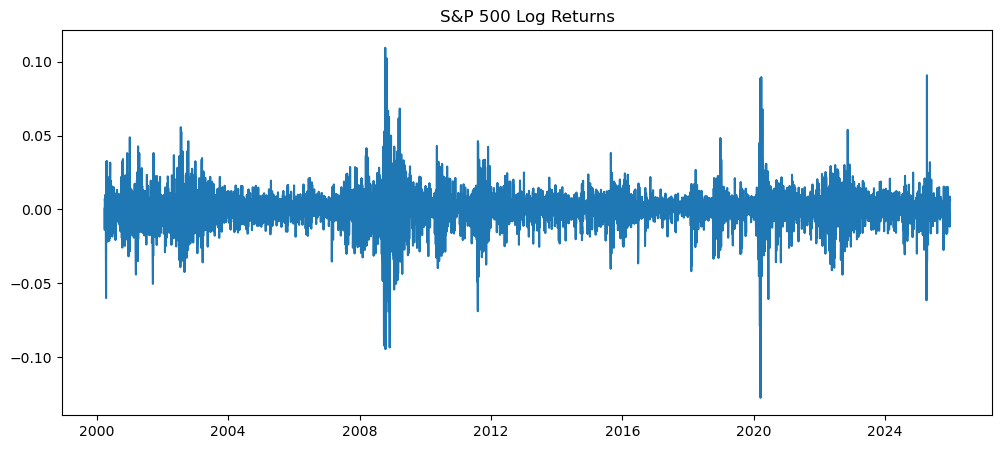

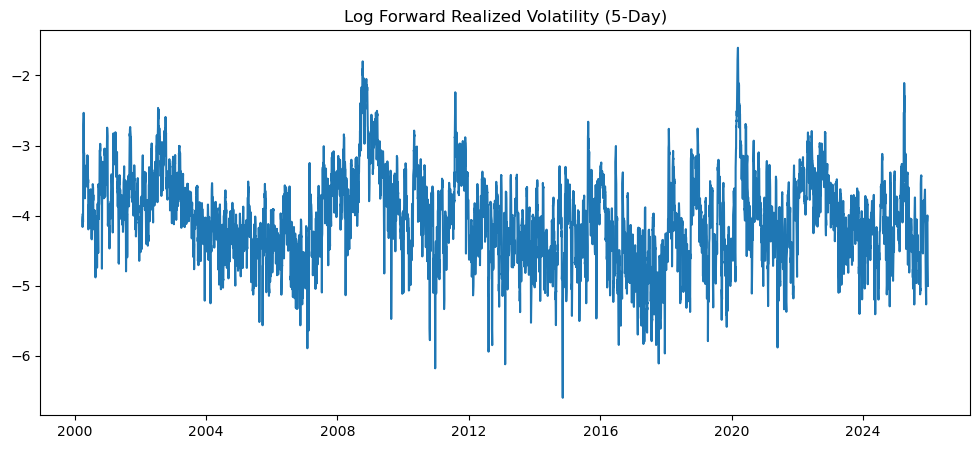

In [10]:
# Visual inspection of log returns and target volatility

plt.figure(figsize=(12,5))
plt.plot(sp500_data["log_return"])
plt.title("S&P 500 Log Returns")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(sp500_data["log_target_vol"])
plt.title("Log Forward Realized Volatility (5-Day)")
plt.show()

Large spikes correspond to crises (eg. 2020). We do not remove extrem events as they are economically meaningful.  
Financial stress periods are crucial for volatility modeling.

In [11]:
# Final dataset for feature engineering and modeling
df_model = sp500_data[[
    "Close",
    "Volume",
    "log_return",
    "log_target_vol",
    "vol_5",
    "vol_10",
    "vol_20",
    "vol_60"
]].copy()

df_model.head()

Price,Close,Volume,log_return,log_target_vol,vol_5,vol_10,vol_20,vol_60
Date,,,,,,,,
2000-03-29,1508.520020,1061900000,0.000524,-3.986406,0.010306,0.017178,0.017494,0.015679
2000-03-30,1487.920044,1193400000,-0.013750,-4.161130,0.006545,0.011939,0.017959,0.014914
2000-03-31,1498.579956,1227400000,0.007139,-4.071010,0.008459,0.012036,0.017588,0.014934
2000-04-03,1505.969971,1021700000,0.004919,-4.010000,0.009352,0.011744,0.017190,0.014943
2000-04-04,1494.729980,1515460000,-0.007492,-4.091559,0.008741,0.009256,0.015948,0.014600


# 3. Exploratory Data Analysis

This section investigates the statistical properties of returns and volatility to better understand market dynamics and validate modeling assumptions.

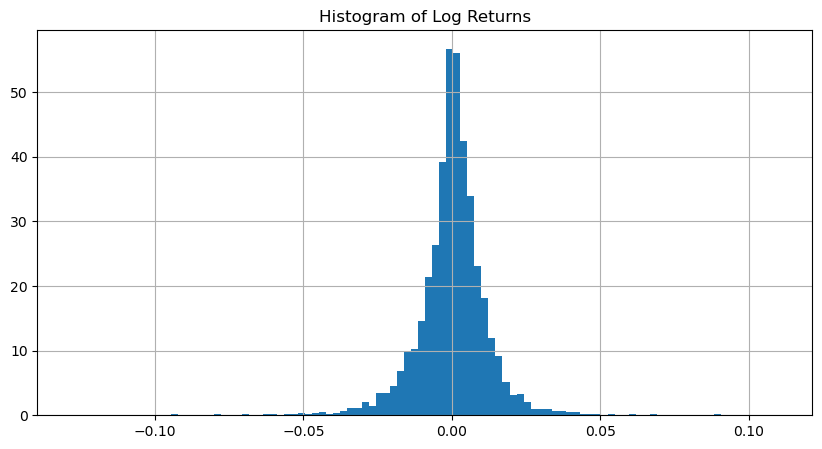

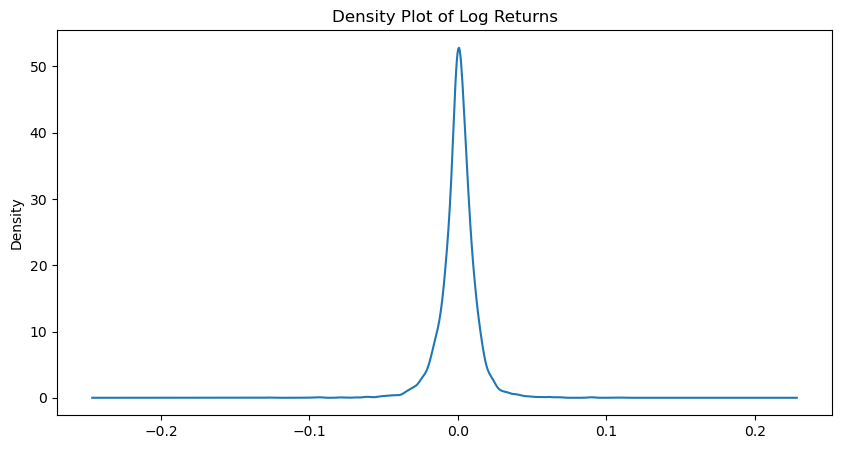

In [12]:
# Distribution of log returns

# Financial returns often exhibit heavy tails and skewness, deviating from normality.
plt.figure(figsize=(10,5))
sp500_data["log_return"].hist(bins=100, density=True)
plt.title("Histogram of Log Returns")
plt.show()

sp500_data["log_return"].plot(kind="kde", figsize=(10,5))
plt.title("Density Plot of Log Returns")
plt.show()

The distribution exhibits a pronounced peak and heavy tails relative to a normal distribution, indicating excess kurtosis. This suggests that Gaussian assumptions may underestimate extreme market movements.

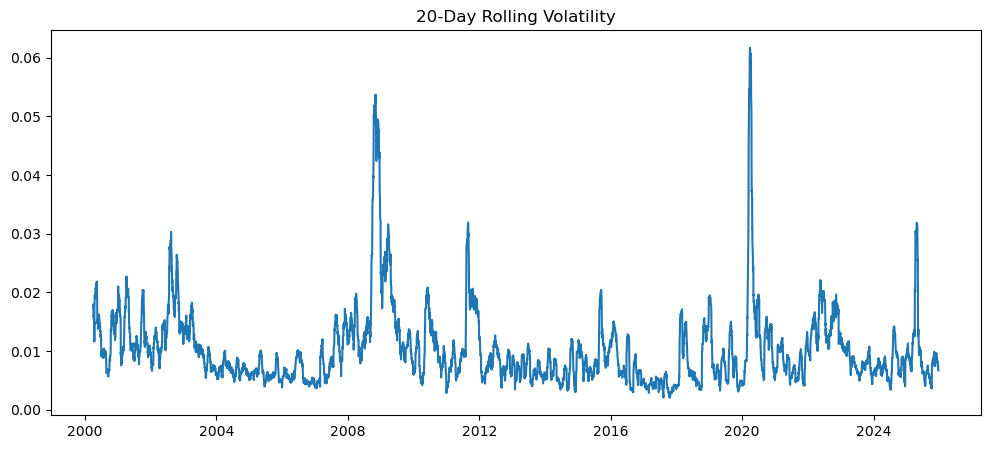

In [13]:
# Volatility dynamics, time series plot of 20-day rolling volatility
# We focus on the 20-day rolling volatility as a representative medium-term measure for visualization purposes. 
# We can observe periods of elevated volatility (e.g., during financial crises) 
# and calmer periods, illustrating the clustering behavior of volatility.
# Other horizons exhibit similar dynamics and are used later in the modeling stage.

plt.figure(figsize=(12,5))
plt.plot(sp500_data["vol_20"])
plt.title("20-Day Rolling Volatility")
plt.show()

The persistence of high-volatility episodes suggests volatility clustering, a key stylized fact of financial markets.

In [14]:
# Distributional properties of log returns: skewness and kurtosis

from scipy.stats import skew, kurtosis

print("Skewness:", skew(sp500_data["log_return"]))
print("Excess Kurtosis:", kurtosis(sp500_data["log_return"]))

Skewness: -0.3553235438558906
Excess Kurtosis: 10.813326668760315


Positive excess kurtosis confirms fat tails, consistent with financial return distributions



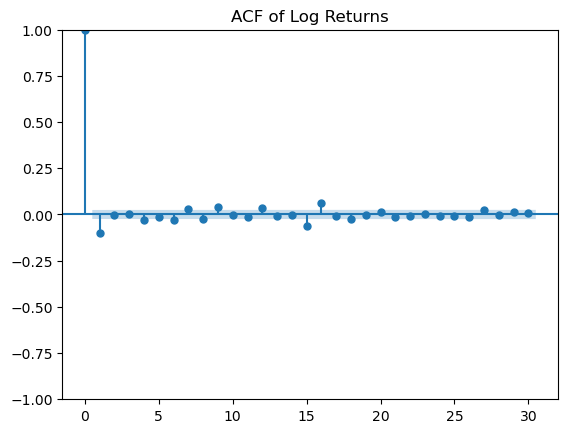

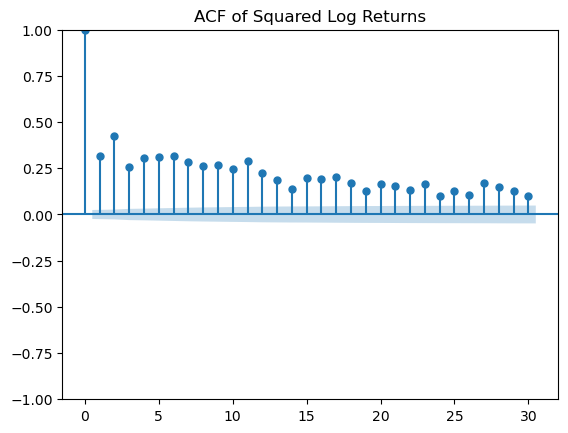

In [15]:
# Autocorrelation - Volatility clustering
# Returns themselves often show little autocorrelation, but their squares exhibit significant autocorrelation.

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(sp500_data["log_return"], lags=30)
plt.title("ACF of Log Returns")
plt.show()

plot_acf(sp500_data["log_return"]**2, lags=30)
plt.title("ACF of Squared Log Returns")
plt.show()

The significant autocorrelation in squared returns confirms volatility persistence and motivates autoregressive volatility models.

In [16]:
# Stationarity test - Augmented Dickey-Fuller (ADF)

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(sp500_data["log_return"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -20.15486115026189
p-value: 0.0


P-value < 0.05 therefore we reject the unit root hypothesis and conclude that log returns are stationary

In [17]:
# Volatility Regime Identification

threshold_high = sp500_data["vol_20"].quantile(0.75)
threshold_low = sp500_data["vol_20"].quantile(0.25)

high_vol_periods = sp500_data[sp500_data["vol_20"] > threshold_high]
low_vol_periods = sp500_data[sp500_data["vol_20"] < threshold_low]

The following visualization illustrates volatility regime dynamics over time:

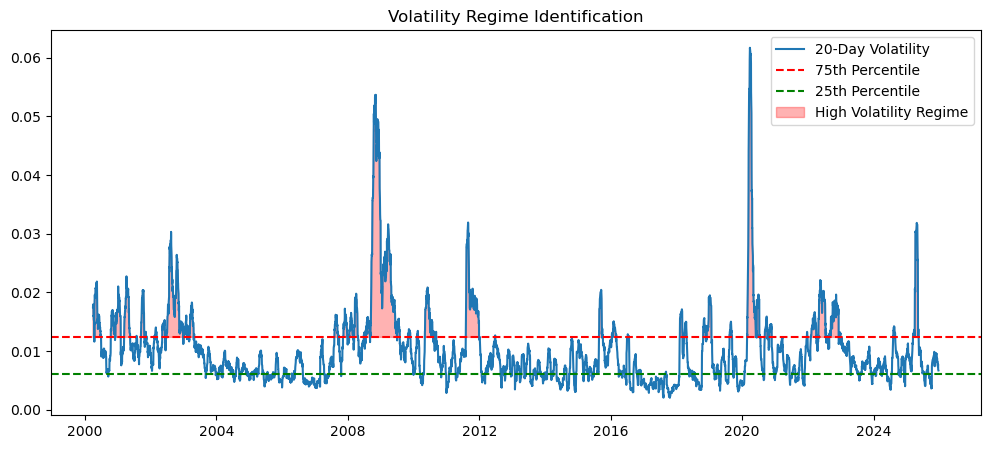

In [18]:
plt.figure(figsize=(12,5))

plt.plot(sp500_data["vol_20"], label="20-Day Volatility")

plt.axhline(threshold_high, color="red", linestyle="--", label="75th Percentile")
plt.axhline(threshold_low, color="green", linestyle="--", label="25th Percentile")

plt.fill_between(
    sp500_data.index,
    sp500_data["vol_20"],
    threshold_high,
    where=sp500_data["vol_20"] > threshold_high,
    color="red",
    alpha=0.3,
    label="High Volatility Regime"
)

plt.title("Volatility Regime Identification")
plt.legend()
plt.show()

The regime classification highlights structural shifts between calm and stress periods. Since predictive relationships may differ across regimes, this motivates using flexible or non-linear models in subsequent sections.

The empirical analysis confirms key stylized facts of financial markets:
- Non-normal return distribution with fat tails  
- Strong volatility clustering  
- Stationary returns  
- Distinct volatility regimes  

These findings justify modeling log-volatility and incorporating multiple volatility horizons in the predictive framework.

# 4. Feature Engineering

Feature engineering plays a critical role in volatility forecasting, as the predictive power of a model often depends on how effectively it captures the underlying dynamics of financial time series. In this section, we construct a rich set of features from the preprocessed dataset to enable robust modeling.

We categorize features into four groups:  
1. Basic Features (Essential)  
2. Advanced Features (Differentiating)  
3. Key Features (Volatility Clustering)  
4. Regime Switching Features  

Each group builds upon previous concepts and enhances model performance by capturing distinct aspects of market behavior.

## 4.1 Basic features  
These features are foundational and commonly used in volatility modeling.

In [19]:
# Lag returns
for lag in [1, 2, 5, 10]:
    df_model[f"log_return_lag_{lag}"] = df_model["log_return"].shift(lag)

# Rolling volatility (as previously computed)
for w in [5, 10, 20, 60]:
    df_model[f"vol_{w}"] = df_model["log_return"].rolling(window=w).std()

# Rolling mean returns
for w in [5, 10, 20]:
    df_model[f"rolling_mean_return_{w}"] = df_model["log_return"].rolling(window=w).mean()

# Rolling max drawdown
def max_drawdown(returns):
    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    return drawdown.min()

df_model["max_drawdown_20"] = df_model["log_return"].rolling(window=20).apply(max_drawdown)

# Volume based features
# Rolling mean volume
df_model["mean_volume_20"] = df_model["Volume"].rolling(window=20).mean()
# Volume / Rolling volume
df_model["volume_ratio_20"] = df_model["Volume"] / df_model["mean_volume_20"]
# Volume volatility
df_model["volume_vol_20"] = df_model["Volume"].rolling(window=20).std()


df_model.head()

Price,Close,Volume,log_return,log_target_vol,vol_5,vol_10,vol_20,vol_60,log_return_lag_1,log_return_lag_2,log_return_lag_5,log_return_lag_10,rolling_mean_return_5,rolling_mean_return_10,rolling_mean_return_20,max_drawdown_20,mean_volume_20,volume_ratio_20,volume_vol_20
Date,,,,,,,,,,,,,,,,,,,
2000-03-29,1508.520020,1061900000,0.000524,-3.986406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-30,1487.920044,1193400000,-0.013750,-4.161130,NaN,NaN,NaN,NaN,0.000524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-03-31,1498.579956,1227400000,0.007139,-4.071010,NaN,NaN,NaN,NaN,-0.013750,0.000524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-03,1505.969971,1021700000,0.004919,-4.010000,NaN,NaN,NaN,NaN,0.007139,-0.013750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-04-04,1494.729980,1515460000,-0.007492,-4.091559,0.008741,NaN,NaN,NaN,0.004919,0.007139,NaN,NaN,-0.001732,NaN,NaN,NaN,NaN,NaN,NaN


These basic features provide a foundation that is both interpretable and predictive.

## 4.2 Advanced Features  
To capture more nuanced aspects of market dynamics, we introduce advanced features inspired by empirical studies and technical analysis.

In [20]:
# Rolling skewness and kurtosis
df_model["skewness_20"] = df_model["log_return"].rolling(window=20).skew()
df_model["kurtosis_20"] = df_model["log_return"].rolling(window=20).kurt()

# Absolute returns (proxy for leverage effect)
df_model["abs_log_return"] = np.abs(df_model["log_return"])

# Volatility ratio (short-term / long-term)
df_model["vol_ratio_5_60"] = df_model["vol_5"] / df_model["vol_60"]

# Dummy variables for bull/bear regime (using MA crossover)
df_model["ma_5"] = df_model["Close"].rolling(window=5).mean()
df_model["ma_20"] = df_model["Close"].rolling(window=20).mean()
df_model["bull_bear"] = (df_model["ma_5"] > df_model["ma_20"]).astype(int)

# Volume spikes and volatility
df_model["volume_spike"] = (df_model["Volume"] > df_model["Volume"].rolling(window=20).mean() * 1.5).astype(int)
df_model["vol_volume_20"] = df_model["Volume"].rolling(window=20).std()

df_model.head()

Price,Close,Volume,log_return,log_target_vol,vol_5,vol_10,vol_20,vol_60,log_return_lag_1,log_return_lag_2,...,volume_vol_20,skewness_20,kurtosis_20,abs_log_return,vol_ratio_5_60,ma_5,ma_20,bull_bear,volume_spike,vol_volume_20
Date,,,,,,,,,,,,,,,,,,,,,
2000-03-29,1508.520020,1061900000,0.000524,-3.986406,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000524,NaN,NaN,NaN,0,0,NaN
2000-03-30,1487.920044,1193400000,-0.013750,-4.161130,NaN,NaN,NaN,NaN,0.000524,NaN,...,NaN,NaN,NaN,0.013750,NaN,NaN,NaN,0,0,NaN
2000-03-31,1498.579956,1227400000,0.007139,-4.071010,NaN,NaN,NaN,NaN,-0.013750,0.000524,...,NaN,NaN,NaN,0.007139,NaN,NaN,NaN,0,0,NaN
2000-04-03,1505.969971,1021700000,0.004919,-4.010000,NaN,NaN,NaN,NaN,0.007139,-0.013750,...,NaN,NaN,NaN,0.004919,NaN,NaN,NaN,0,0,NaN
2000-04-04,1494.729980,1515460000,-0.007492,-4.091559,0.008741,NaN,NaN,NaN,0.004919,0.007139,...,NaN,NaN,NaN,0.007492,NaN,1499.143994,NaN,0,0,NaN


These features enhance model sensitivity to asymmetries, regime transitions, and market momentum.

## 4.3 Key Features  
This group focuses on capturing the persistence and clustering properties of volatility — core stylized facts in financial markets.

In [ ]:
# Lag volatility (t-1, t-5)
df_model["vol_lag_1"] = df_model["vol_20"].shift(1)
df_model["vol_lag_5"] = df_model["vol_20"].shift(5)

# Volatility persistence features
df_model["volatility_persistence"] = df_model["vol_5"] / df_model["vol_20"]

# Conditional volatility (e.g., rolling variance of squared returns)
df_model["cond_vol_20"] = df_model["log_return"].rolling(window=20).apply(lambda x: np.std(x**2))

These features directly model the temporal dependencies in volatility, which are crucial for forecasting models.

## 4.5 Regime Switching Features  
Volatility often behaves differently under different market conditions. These features aim to detect and encode regime changes that can be used by non-linear models.

In [ ]:
# Technical indicators
from ta.trend import MACD

# RSI
delta = df_model["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df_model["RSI"] = 100 - (100 / (1 + rs))

# MACD
macd = MACD(df_model["Close"], window_slow=26, window_fast=12, window_sign=9)
df_model["macd"] = macd.macd()
df_model["macd_signal"] = macd.macd_signal()

# Market stress indicator 
df_model["stress_score"] = (df_model["vol_20"] - df_model["vol_60"]) / df_model["vol_60"]

# Volatility regime dummies
high_vol = df_model["vol_20"] > df_model["vol_20"].quantile(0.75)
low_vol = df_model["vol_20"] < df_model["vol_20"].quantile(0.25)

df_model["high_vol_regime"] = high_vol.astype(int)
df_model["low_vol_regime"] = low_vol.astype(int)

These regime-based features allow the model to adapt to shifts in market behavior and improve generalization.

In [23]:
# Hanbdling missing values after feature engineering
df_model = df_model.dropna().copy()

This feature engineering pipeline provides a comprehensive set of inputs that capture:
- Historical patterns in returns and volatility
- Dynamic market regimes through technical indicators
- Volatility clustering and persistence
- Asymmetric behavior (e.g., leverage effect)  

This rich set of features enables both linear and non-linear models to perform well in forecasting S&P 500 volatility.

# 5. Time-Series Chronological Split (2000-2025)

Train : 2000–2016  
-    Covering multiple regimes (dot-com, GFC, QE)

Validation : 2017-2019  
-    Capturing late-cycle volatility

Test : 2020–2025  
-    Including COVID shock and inflation regime

In [24]:
train = df_model.loc["2000":"2016"].copy()
val   = df_model.loc["2017":"2019"].copy()
test  = df_model.loc["2020":"2025"].copy()

X_train = train.drop("log_target_vol", axis=1)
y_train = train["log_target_vol"]

X_val = val.drop("log_target_vol", axis=1)
y_val = val["log_target_vol"]

X_test = test.drop("log_target_vol", axis=1)
y_test = test["log_target_vol"]

# 6. Feature Importance and Intelligence Reduction

Objective :  
. Identify the most predictive features  
. Remove redundant predictors  
. Reduce overfitting risk  
. Improve model interpretability  

All procedures are performed strictly on the training set to avoid look-ahead bias.

In [25]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [26]:
# Baseline Model for Diagnostic Importance
# We use a Random Forest Regressor as a baseline model to assess feature importance and identify key predictors of future volatility.

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

val_score_scaled = rf.score(X_val_scaled, y_val)
val_score_scaled

0.37545542610518556

In [27]:
# Model-Based Feature Importance

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)

,feature,importance
30,cond_vol_20,0.417722
14,max_drawdown_20,0.114324
31,RSI,0.080932
4,vol_10,0.080219
5,vol_20,0.064076
6,vol_60,0.048236
11,rolling_mean_return_5,0.027601
0,Close,0.027114
12,rolling_mean_return_10,0.019303
15,mean_volume_20,0.016095


In [28]:
# Permutation Importance
# To avoid bias from tree splitting mechanisms
# Permutation importance measures the drop in model performance when a feature's values are randomly shuffled, reflecting real predictive contribution.

from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_train_scaled,
    y_train,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": perm.importances_mean
}).sort_values(by="importance", ascending=False)

perm_df.head(20)

,feature,importance
30,cond_vol_20,0.206235
31,RSI,0.088119
14,max_drawdown_20,0.076742
6,vol_60,0.068810
11,rolling_mean_return_5,0.034540
4,vol_10,0.034306
0,Close,0.031936
12,rolling_mean_return_10,0.022056
15,mean_volume_20,0.015454
5,vol_20,0.011226


In [29]:
# Multicollinearity Check
# We compute the correlation matrix to identify highly correlated features that may cause multicollinearity issues

corr_matrix = X_train.corr().abs()

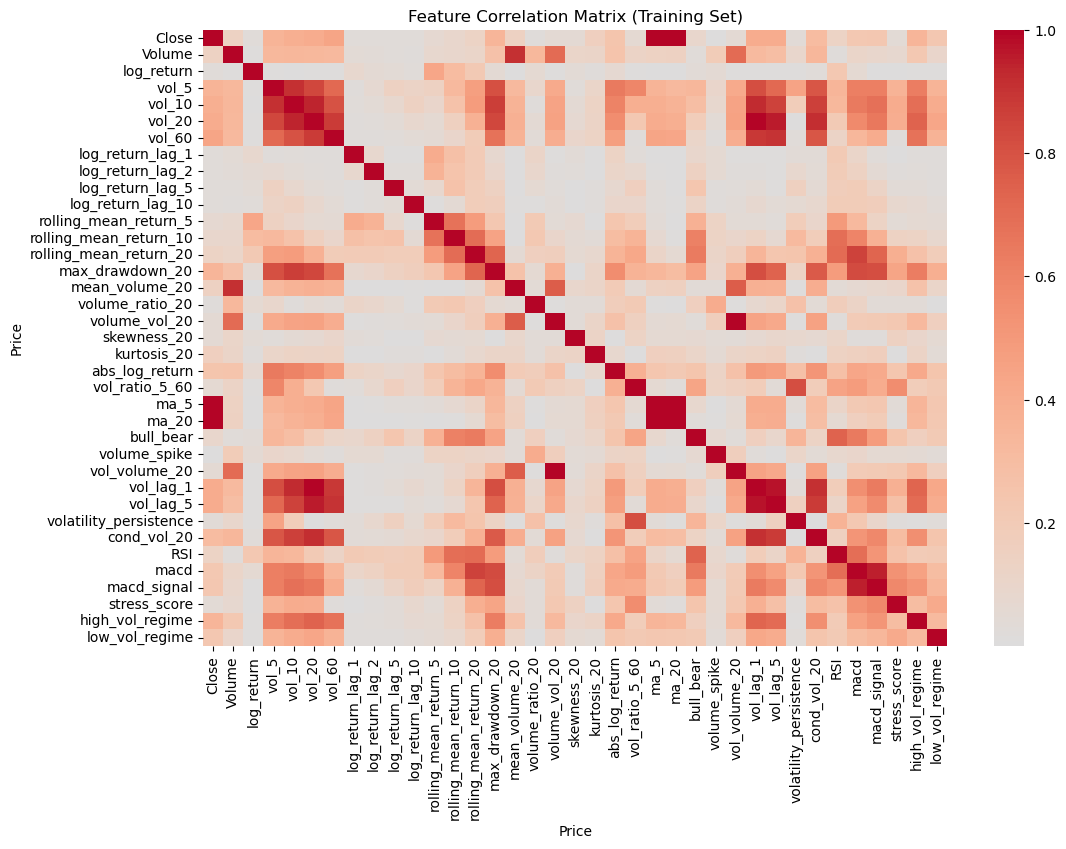

In [30]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (Training Set)")
plt.show()

In [31]:
# Intelligent Feature Reduction Strategy

# We define a threshold for feature importance (0.001) to select only the most relevant features for modeling.

importance_treshold = 0.001

selected_features = perm_df[perm_df["importance"] > importance_treshold]["feature"]

X_train_red = X_train[selected_features]
X_val_red   = X_val[selected_features]
X_test_red  = X_test[selected_features]

# Removing highly correlated features (correlation > 0.9) to mitigate multicollinearity issues and improve model stability.
# create importance dictionary for feature importance values
importance_dict = dict(zip(perm_df["feature"], perm_df["importance"]))

# compute correlation matrix for the reduced feature set
corr_matrix_red = X_train_red.corr().abs()

# keep only upper triangle of the correlation matrix
upper = corr_matrix_red.where(
    np.triu(np.ones(corr_matrix_red.shape), k=1).astype(bool)
)

to_drop_corr = set()
# loop through correlated pairs
for col in upper.columns:
    high_corr_features = upper.index[upper[col] > 0.9].tolist()
    
    for row in high_corr_features:
        
        # Compare permutation importance
        if importance_dict[row] < importance_dict[col]:
            to_drop_corr.add(row)
        else:
            to_drop_corr.add(col)

X_train_red = X_train_red.drop(columns=to_drop_corr)
X_val_red   = X_val_red.drop(columns=to_drop_corr)
X_test_red  = X_test_red.drop(columns=to_drop_corr)

In [32]:
# Validation check

rf.fit(X_train_red, y_train)
val_score_red = rf.score(X_val_red, y_val)
val_score_red

0.3699635048850002

In [33]:
X_train_red.columns.tolist()

['cond_vol_20',
 'RSI',
 'max_drawdown_20',
 'vol_60',
 'rolling_mean_return_5',
 'vol_10',
 'Close',
 'rolling_mean_return_10',
 'mean_volume_20',
 'rolling_mean_return_20',
 'macd_signal',
 'kurtosis_20',
 'stress_score',
 'vol_volume_20',
 'skewness_20',
 'volume_ratio_20',
 'volatility_persistence',
 'vol_ratio_5_60',
 'log_return']

In [34]:
import joblib

joblib.dump(X_train_red, "../models/X_train_red.pkl")
joblib.dump(X_val_red,   "../models/X_val_red.pkl")
joblib.dump(X_test_red,  "../models/X_test_red.pkl")

joblib.dump(y_train, "../models/y_train.pkl")
joblib.dump(y_val,   "../models/y_val.pkl")
joblib.dump(y_test,  "../models/y_test.pkl")

joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(to_drop_corr, "../models/to_drop_corr.pkl")
joblib.dump(df_model, "../models/df_model.pkl")

['../models/df_model.pkl']